In [24]:
import pennylane as qml
import numpy as np
import sys
import pennylane.utils
from pennylane.utils import decompose_hamiltonian
sys.path.append('..')
from QHyper.optimizers.CEM import CEM
from QHyper.optimizers.random import Random
from QHyper.optimizers.qml_gradient_descent import QmlGradientDescent
from QHyper.solvers.QAOA.core import QAOA

In [25]:
A = np.array(
[[-2, 0, 0, 0], [0,  1,  0, 0], [0,  0, 5, 0], [0, 0, 0,  -6]])
coeffs, obs_list = decompose_hamiltonian(A)
coeffs

[-0.5, 2.0, -3.5]

In [26]:
obs_list

[Identity(wires=[0]) @ Identity(wires=[1]),
 Identity(wires=[0]) @ PauliZ(wires=[1]),
 PauliZ(wires=[0]) @ PauliZ(wires=[1])]

In [27]:
H = qml.Hamiltonian(coeffs, obs_list)

In [28]:
from QHyper.problems.Workflowtest import WorkflowtestProblem

In [29]:
wft = WorkflowtestProblem()

6.0*x0 + 8.0*x1 + 8.0*x2 + 3.0*x3 + 4.0*x4 + 4.0*x5 + 12.0*x6 + 16.0*x7 + 16.0*x8
[x0**2 + 2*x0*x1 + 2*x0*x2 - 2*x0 + x1**2 + 2*x1*x2 - 2*x1 + x2**2 - 2*x2 + x3**2 + 2*x3*x4 + 2*x3*x5 - 2*x3 + x4**2 + 2*x4*x5 - 2*x4 + x5**2 - 2*x5 + x6**2 + 2*x6*x7 + 2*x6*x8 - 2*x6 + x7**2 + 2*x7*x8 - 2*x7 + x8**2 - 2*x8, 36.0*x0**2 + 24.0*x0*x1 + 48.0*x0*x10 + 24.0*x0*x11 + 12.0*x0*x12 + 48.0*x0*x2 + 36.0*x0*x3 + 12.0*x0*x4 + 24.0*x0*x5 + 144.0*x0*x6 + 48.0*x0*x7 + 96.0*x0*x8 + 96.0*x0*x9 - 228.0*x0 + 4.0*x1**2 + 16.0*x1*x10 + 8.0*x1*x11 + 4.0*x1*x12 + 16.0*x1*x2 + 12.0*x1*x3 + 4.0*x1*x4 + 8.0*x1*x5 + 48.0*x1*x6 + 16.0*x1*x7 + 32.0*x1*x8 + 32.0*x1*x9 - 76.0*x1 + 16*x10**2 + 16*x10*x11 + 8*x10*x12 + 32.0*x10*x2 + 24.0*x10*x3 + 8.0*x10*x4 + 16.0*x10*x5 + 96.0*x10*x6 + 32.0*x10*x7 + 64.0*x10*x8 + 64*x10*x9 - 152*x10 + 4*x11**2 + 4*x11*x12 + 16.0*x11*x2 + 12.0*x11*x3 + 4.0*x11*x4 + 8.0*x11*x5 + 48.0*x11*x6 + 16.0*x11*x7 + 32.0*x11*x8 + 32*x11*x9 - 76*x11 + x12**2 + 8.0*x12*x2 + 6.0*x12*x3 + 2.0*x12*x4 + 4

In [30]:
solver = QAOA(
    problem=wft,
    platform="pennylane",
    optimizer=QmlGradientDescent(3, qml.QNGOptimizer()),
    layers=1,
    weights=[1.0, 20.0, 10.0],
    angles=[[0.5]*1, [0.5]*1],
    # mixer: str=,
    # backend=
)

In [31]:
H=solver.get_cost_operator()

In [32]:
H

<Hamiltonian: terms=92, wires=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]>


In [33]:
dev = qml.device("default.qubit", wires=13)
a=1

@qml.qnode(dev)
def circuit(num):
    i=0
    while num>=1:
        if num%2==1:    
            qml.PauliX(i)
        num=num//2
        i=i+1
    return qml.expval(H)
circuit(a).item(0)

-1934.0

In [41]:
mydict={}
qsize=3
smaller_size=pow(2,qsize)
import random
ran=random.sample(range(1, 100), smaller_size)
for i in range(0,smaller_size):
    x=ran[i]
    y=circuit(x).item(0)
    mydict[x]=y



In [42]:
mydict

{34: -1388.0,
 30: -2777.0,
 17: -2200.0,
 13: -3253.0,
 54: -2586.0,
 24: -1353.0,
 75: -3461.0,
 87: -3192.0}

In [43]:
np.array(list(dict(sorted(mydict.items())).values()))

array([-3253., -2200., -1353., -2777., -1388., -2586., -3461., -3192.])

In [45]:
HA = np.zeros((smaller_size, smaller_size), float)

np.fill_diagonal(HA, np.array(list(dict(sorted(mydict.items())).values())))

HA

array([[-3253.,     0.,     0.,     0.,     0.,     0.,     0.,     0.],
       [    0., -2200.,     0.,     0.,     0.,     0.,     0.,     0.],
       [    0.,     0., -1353.,     0.,     0.,     0.,     0.,     0.],
       [    0.,     0.,     0., -2777.,     0.,     0.,     0.,     0.],
       [    0.,     0.,     0.,     0., -1388.,     0.,     0.,     0.],
       [    0.,     0.,     0.,     0.,     0., -2586.,     0.,     0.],
       [    0.,     0.,     0.,     0.,     0.,     0., -3461.,     0.],
       [    0.,     0.,     0.,     0.,     0.,     0.,     0., -3192.]])

In [46]:
coeffs, obs_list = decompose_hamiltonian(HA)
coeffs

[-2526.25, 162.5, 169.5, -126.25, 130.5, -69.75, -500.25, -493.0]

In [47]:
obs_list

[Identity(wires=[0]) @ Identity(wires=[1]) @ Identity(wires=[2]),
 Identity(wires=[0]) @ Identity(wires=[1]) @ PauliZ(wires=[2]),
 Identity(wires=[0]) @ PauliZ(wires=[1]) @ Identity(wires=[2]),
 Identity(wires=[0]) @ PauliZ(wires=[1]) @ PauliZ(wires=[2]),
 PauliZ(wires=[0]) @ Identity(wires=[1]) @ Identity(wires=[2]),
 PauliZ(wires=[0]) @ Identity(wires=[1]) @ PauliZ(wires=[2]),
 PauliZ(wires=[0]) @ PauliZ(wires=[1]) @ Identity(wires=[2]),
 PauliZ(wires=[0]) @ PauliZ(wires=[1]) @ PauliZ(wires=[2])]

In [48]:
HAd=qml.Hamiltonian(coeffs,obs_list)

In [49]:
HAd

  (-2526.25) [I0 I1 I2]
+ (-500.25) [Z0 Z1 I2]
+ (-493.0) [Z0 Z1 Z2]
+ (-126.25) [I0 Z1 Z2]
+ (-69.75) [Z0 I1 Z2]
+ (130.5) [Z0 I1 I2]
+ (162.5) [I0 I1 Z2]
+ (169.5) [I0 Z1 I2]


In [56]:
import pennylane.qaoa.layers
from pennylane.qaoa.layers import cost_layer,mixer_layer
import pennylane.qaoa
from pennylane.qaoa import x_mixer
dev = qml.device('default.qubit', wires=2)

@qml.qnode(dev)
def circuit(gamma,alpha, H,size):

    for i in range(size):
        qml.Hadamard(wires=i)
    cost_layer(gamma, H)
    mixer_h = x_mixer(range(size))
    mixer_layer(alpha, mixer_h)

    return [qml.expval(qml.PauliZ(wires=i)) for i in range(size)]

C:\Users\kzaja\AppData\Local\Temp\ipykernel_14460\2426504762.py:3: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


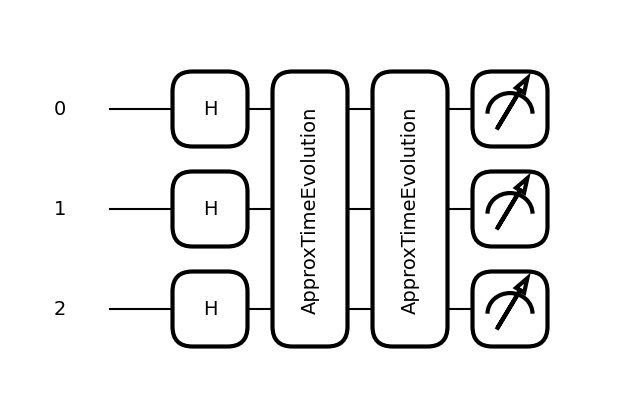

In [57]:

import matplotlib
fig, ax = qml.draw_mpl(circuit)(0.1,0.1,HAd,qsize)
fig.show()